## **Initial setup**

Install Bambu and required packages:

In [3]:
!echo "deb http://ppa.launchpad.net/git-core/ppa/ubuntu $(cat /etc/os-release | grep UBUNTU_CODENAME | sed 's/.*=//g') main" >> /etc/apt/sources.list.d/git-core.list
!apt-key adv --keyserver keyserver.ubuntu.com --recv-keys A1715D88E1DF1F24
!apt-get update
!apt-get install -y --no-install-recommends build-essential ca-certificates gcc-multilib g++-multilib git libtinfo5 verilator wget
!wget https://release.bambuhls.eu/appimage/bambu-latest.AppImage
!chmod +x bambu-*.AppImage
!ln -sf $PWD/bambu-*.AppImage /bin/bambu
!ln -sf $PWD/bambu-*.AppImage /bin/panda_shell
!ln -sf $PWD/bambu-*.AppImage /bin/spider
!git clone --depth 1 --filter=blob:none --branch dev/panda --sparse https://github.com/ferrandi/PandA-bambu.git
%cd PandA-bambu
!git sparse-checkout set documentation/bambu101
%cd ..
!mv PandA-bambu/documentation/bambu101/* .

Executing: /tmp/apt-key-gpghome.3LaEmeOmsp/gpg.1.sh --keyserver keyserver.ubuntu.com --recv-keys A1715D88E1DF1F24
gpg: key A1715D88E1DF1F24: "Launchpad PPA for Ubuntu Git Maintainers" not changed
gpg: Total number processed: 1
gpg:              unchanged: 1
Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 https://cli.github.com/packages stable InRelease
Hit:5 http://ppa.launchpad.net/git-core/ppa/ubuntu jammy InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu 

# Introduction to High-Level Synthesis

The **High-Level Synthesis (HLS)** process transforms a high-level language description into a hardware design. The input representation can be any high-level language supported by the HLS tool (e.g., **C/C++, FORTRAN**), and the tool takes care of both optimization and translation to the output RTL-level language (e.g., **Verilog** or **VHDL**).

The flow is similar to that of a standard compiler like **GCC** or **Clang**. After preprocessing and generic optimization of the input code, hardware-oriented transformations are applied. Finally, the backend translates the optimized code into a hardware design by:

- Instantiating functional units,
- Scheduling operations in time,
- Binding each operation to hardware resources.

This process enables software developers to write hardware-accelerated code using familiar programming languages and paradigms.

---

**Bambu** is an open-source High-Level Synthesis (HLS) tool developed by [Politecnico di Milano](https://github.com/ferrandi/PandA-bambu). It allows the generation of **RTL hardware designs** from high-level languages, targeting **FPGA** and **ASIC** platforms.

Bambu is designed to be flexible and research-friendly, making it suitable both for academic study and for developing efficient, real-world accelerators from C/C++ code.

Bambu is distributed as a standalone **AppImage**, making it easy to run in a **Colab notebook** or on any Linux machine without requiring complex installation steps.


To synthesize hardware from C code, we will launch `bambu` through the command-line. You can explore all available options and features by printing its help menu.

In [4]:
!bambu --help


********************************************************************************
                    ____                  _
                   | __ )  __ _ _ __ ___ | |_   _   _
                   |  _ \ / _` | '_ ` _ \| '_ \| | | |
                   | |_) | (_| | | | | | | |_) | |_| |
                   |____/ \__,_|_| |_| |_|_.__/ \__,_|

********************************************************************************
                         High-Level Synthesis Tool

                         Politecnico di Milano - DEIB
                          System Architectures Group
********************************************************************************
                Copyright (C) 2004-2024 Politecnico di Milano
 Version: PandA 2024.10 - Revision c2ba6936ca2ed63137095fea0b630a1c66e20e63-main

Usage:
       bambu [Options] <source_file> [<constraints_file>] [<technology_file>]

Options:

  General options:

    --help, -h
        Display this usage information.

    --version, -V

## Input Application

The HLS tool requires an input description of the application to be translated into hardware. The input must define a **single top-level function** that handles all inputs and outputs. This function will be synthesized into hardware by the tool.

In this example, we use a simple **CRC kernel implementation** as the input application.

You can inspect the content of the source file below:

In [5]:
!cat /content/basic_usage/icrc.c

unsigned short icrc1(unsigned short crc, unsigned char onech)
{
    int i;
    unsigned short ans=(crc^onech << 8);
    
    for (i=0;i<8;i++) {
        if (ans & 0x8000)
            ans = (ans <<= 1) ^ 4129;
        else
            ans <<= 1;
    }
    return ans;
}



## Miniamal set of options

The HLS tool also requires some specification about the output interface to be generated.

### Top level interface

As a standard compiler needs a main function to know where to start, the HLS tool needs a top level interface to be used as the interface of the generated hardware module.  
Following the CRC example, this can be specified through the `--top-fname=icrc1` command line option. This will let the HLS tool know the hardware design interface has to be the same of function `icrc1` from the input representation.

### Target hardware device

The HLS tool needs to know what is the hardware target for which the RTL description needs to be generated since different assumptions are made based on the target device.  
For this example a Xilinx FPGA board has been selected (`xc7z020-1clg484`) and is required through the `--device-name=xc7z020-1clg484-VVD` command line option.  
Furthermore, the required clock period of the generated accelerator needs to be specified through the `--clock-period` option.  
For a target frequency of 200 MHz, `--clock-period=5` has to be used, as Bambu specifies the clock period in nanoseconds.

### Generated design verification

Bambu HLS offers the possibility to run a verification of the output design with respect to the input representation.  
This can be required by passing a testbench file where the top level function is executed.  
The file is passed to the tool through `--generate-tb=testbench.c`.

Below we print the testbench file used to verify the `icrc1` function:


In [6]:
!cat /content/basic_usage/testbench.c

#include "icrc.h"
#include <stdio.h>

unsigned short main()
{
   unsigned short crc = 245;
   unsigned char onech = 5;

   unsigned short res = icrc1(crc, onech);

   crc = 134;
   onech = 3;

   res += icrc1(crc, onech);

   printf("res = %d\n", res);
   
   return res;
}

## Generating the Accelerator

Now we are ready to generate the hardware design for the `icrc1` function using the following command:

In [7]:
%cd /content/basic_usage
!bambu icrc.c --top-fname=icrc1 --device-name=xc7z020-1clg484-VVD --clock-period=5 --generate-tb=testbench.c --simulate -v4

/content/basic_usage
 ==  Bambu executed with: /tmp/.mount_bambu3vktWP/usr/bin/bambu --top-fname=icrc1 --device-name=xc7z020-1clg484-VVD --clock-period=5 --generate-tb=testbench.c --simulate -v4 icrc.c 


********************************************************************************
                    ____                  _
                   | __ )  __ _ _ __ ___ | |_   _   _
                   |  _ \ / _` | '_ ` _ \| '_ \| | | |
                   | |_) | (_| | | | | | | |_) | |_| |
                   |____/ \__,_|_| |_| |_|_.__/ \__,_|

********************************************************************************
                         High-Level Synthesis Tool

                         Politecnico di Milano - DEIB
                          System Architectures Group
********************************************************************************
                Copyright (C) 2004-2024 Politecnico di Milano
 Version: PandA 2024.10 - Revision c2ba6936ca2ed63137095fea0b630a1c

# Output hardware design
After the High-Level Synthesis process completes successfully, the generated RTL design can be found in the `/content/basic_usage/icrc1.v` file.

Additionally, the HLS tool produces a synthesis script named `/content/basic_usage/synthesize_Synthesis_icrc1.sh` alongside the Verilog description. This script can be used to run the vendor-specific synthesis tool to generate the bitstream for the target FPGA.

Finally, we can examine the top-level module and inspect its interface.  
We expect to find a `start_port` to trigger the accelerator, along with `done_port`, `clock` and `reset` ports to manage its operation.  
Additionally, there should be a `return_port` for the function result and two separate wires corresponding to the two input parameters.

In [8]:
import re

def print_last_verilog_interface(filename):
    with open(filename, 'r') as f:
        content = f.read()

    modules = re.findall(r'(module\s+\w+\s*\([^;]*?\);)', content, re.DOTALL)

    if not modules:
        print(f"No modules found in {filename}")
        return

    last_module = modules[-1]

    print(f"Interface of the top module in {filename}:\n")
    print(last_module)

print_last_verilog_interface('/content/basic_usage/icrc1.v')

Interface of the top module in /content/basic_usage/icrc1.v:

module icrc1(clock,
  reset,
  start_port,
  crc,
  onech,
  done_port,
  return_port);


# Accelerator Interface - AXI4 Master
In this section, we explore how to guide **Bambu HLS** to synthesize **AXI4 memory-mapped interfaces** using `#pragma` directives. Each exercise demonstrates a different scenario where AXI4 ports are defined through code annotations.

AXI4 (Advanced eXtensible Interface 4) is a widely-used on-chip communication protocol developed by ARM. It supports **high-throughput, memory-mapped data transfers** and is commonly used to connect accelerators to external memory in FPGA and SoC systems.

The goal of these exercises is to understand how different pragmas affect the generation of AXI4 ports and the structure of the synthesized accelerator.

## Bambu Commands Overview

These are the command-line options we will use in this section to run [Bambu](https://github.com/ferrandi/PandA-bambu) for High-Level Synthesis and simulation of C programs.

Below is a description of each option:

<br>

<table style="font-size: 20px;">
  <thead>
    <tr>
      <th style="text-align:left; padding: 8px;">🔧 Option</th>
      <th style="text-align:left; padding: 8px;">📝 Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 8px;"><code>--generate-interface=INFER</code></td>
      <td style="padding: 8px;">Enables parsing of <code>#pragma</code> directives to define memory interfaces for the accelerator.</td>
    </tr>
    <tr>
      <td style="padding: 8px;"><code>--generate-tb=testbench.c</code></td>
      <td style="padding: 8px;">Specifies the C testbench file used during simulation to provide inputs and validate outputs.</td>
    </tr>
    <tr>
      <td style="padding: 8px;"><code>source_file.c</code></td>
      <td style="padding: 8px;">The source file containing the function to synthesize (e.g., <code>sum.c</code>).</td>
    </tr>
    <tr>
      <td style="padding: 8px;"><code>--top-fname=FUNCTION</code></td>
      <td style="padding: 8px;">Defines the top-level function name to be synthetized.</td>
    </tr>
    <tr>
      <td style="padding: 8px;"><code>--simulate</code></td>
      <td style="padding: 8px;">Runs simulation to verify correctness.</td>
    </tr>
    <tr>
      <td style="padding: 8px;"><code>-v4</code></td>
      <td style="padding: 8px;">Sets verbosity level to 4 (detailed logs of all stages).</td>
    </tr>
    <tr>
      <td style="padding: 8px;"><code>--mem-delay-read=VALUE</code></td>
      <td style="padding: 8px;">Sets latency (in cycles) for external memory read accesses (e.g., <code>20</code>).</td>
    </tr>
    <tr>
      <td style="padding: 8px;"><code>--mem-delay-write=VALUE</code></td>
      <td style="padding: 8px;">Sets latency (in cycles) for external memory write accesses (e.g., <code>20</code>).</td>
    </tr>
  </tbody>
</table>


## Exercise 1

In this exercise, we will learn how to add an **AXI4** port to a function using the `#pragma HLS interface` directive. We will analyze the different clauses of the pragma used to control the interface generation, focusing on how to specify the target parameter, the type of interface, and the behavior of the memory access offset.


In [9]:
%cd /content/Axi4/Exercise1
print("=== Source file: read.c ===\n")
!cat read.c
print("\n\n=== Testbench file: testbench.c ===\n")
!cat testbench.c

/content/Axi4/Exercise1
=== Source file: read.c ===

#pragma HLS interface port = data mode = m_axi offset = direct
short int read(short int* data)
{
   return *(data);
}

=== Testbench file: testbench.c ===

#include "read.h"

int main()
{
   short int A[20];

   for(int i = 0; i < 20; i++)
   {
      A[i] = (short int)i;
   }

   return read(A);
}

The following pragma is used in this exercise to specify the AXI4 interface:

```c
#pragma HLS interface port = data mode = m_axi offset = direct


| Clause                  | Meaning                                                                                                                                                            |
| ----------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| `#pragma HLS interface` | This is a **directive for Bambu**, used to specify how function arguments should be mapped to hardware interfaces.                    |
| `port = data`           | Specifies that the pragma applies to the function parameter named `data`.                                                                                          |
| `mode = m_axi`          | Requests synthesis of an **AXI4 memory-mapped interface** for this port. This allows external memory accesses via the AXI4 protocol.                     |
| `offset = direct`       | Indicates that the base address of the AXI4 interface is **directly derived from the input pointer**. Subsequent accesses are linear and relative to this address. |


Now, we run Bambu to simulate the accelerator behavior using the source code and testbench introduced earlier. This step will generate the AXI4 interface as specified by the pragma and verify the functionality through simulation.


In [10]:
%cd /content/Axi4/Exercise1
!bambu --generate-interface=INFER --generate-tb=testbench.c read.c --top-fname=read --simulate -v4

/content/Axi4/Exercise1
 ==  Bambu executed with: /tmp/.mount_bambux4KM6E/usr/bin/bambu --generate-interface=INFER --generate-tb=testbench.c --top-fname=read --simulate -v4 read.c 


********************************************************************************
                    ____                  _
                   | __ )  __ _ _ __ ___ | |_   _   _
                   |  _ \ / _` | '_ ` _ \| '_ \| | | |
                   | |_) | (_| | | | | | | |_) | |_| |
                   |____/ \__,_|_| |_| |_|_.__/ \__,_|

********************************************************************************
                         High-Level Synthesis Tool

                         Politecnico di Milano - DEIB
                          System Architectures Group
********************************************************************************
                Copyright (C) 2004-2024 Politecnico di Milano
 Version: PandA 2024.10 - Revision c2ba6936ca2ed63137095fea0b630a1c66e20e63-main

Paramet

Now that we have run Bambu, let's look at the ports of the top-level function by extracting the interface of the top module generated.


In [11]:
import re

def print_last_verilog_interface(filename):
    with open(filename, 'r') as f:
        content = f.read()

    modules = re.findall(r'(module\s+\w+\s*\([^;]*?\);)', content, re.DOTALL)

    if not modules:
        print(f"No modules found in {filename}")
        return

    last_module = modules[-1]

    print(f"Interface of the top module in {filename}:\n")
    print(last_module)

print_last_verilog_interface('/content/Axi4/Exercise1/read.v')

Interface of the top module in /content/Axi4/Exercise1/read.v:

module read(clock,
  reset,
  start_port,
  data,
  cache_reset,
  m_axi_data_awready,
  m_axi_data_wready,
  m_axi_data_bid,
  m_axi_data_bresp,
  m_axi_data_buser,
  m_axi_data_bvalid,
  m_axi_data_arready,
  m_axi_data_rid,
  m_axi_data_rdata,
  m_axi_data_rresp,
  m_axi_data_rlast,
  m_axi_data_ruser,
  m_axi_data_rvalid,
  done_port,
  return_port,
  m_axi_data_awid,
  m_axi_data_awaddr,
  m_axi_data_awlen,
  m_axi_data_awsize,
  m_axi_data_awburst,
  m_axi_data_awlock,
  m_axi_data_awcache,
  m_axi_data_awprot,
  m_axi_data_awqos,
  m_axi_data_awregion,
  m_axi_data_awuser,
  m_axi_data_awvalid,
  m_axi_data_wdata,
  m_axi_data_wstrb,
  m_axi_data_wlast,
  m_axi_data_wuser,
  m_axi_data_wvalid,
  m_axi_data_bready,
  m_axi_data_arid,
  m_axi_data_araddr,
  m_axi_data_arlen,
  m_axi_data_arsize,
  m_axi_data_arburst,
  m_axi_data_arlock,
  m_axi_data_arcache,
  m_axi_data_arprot,
  m_axi_data_arqos,
  m_axi_data_arreg

## Exercise 2

In this exercise, we will see how using **multiple `#pragma HLS interface` directives** allows us to generate **distinct AXI4 ports**, one for each function parameter. Each pragma is applied to a different pointer, and Bambu will generate a dedicated AXI4 memory interface for each, named after the corresponding parameter. This is useful when your accelerator needs to access multiple independent memory regions in parallel.


In [12]:
%cd /content/Axi4/Exercise2
print("=== Source file: sum.c ===\n")
!cat sum.c
print("\n\n=== Testbench file: testbench.c ===\n")
!cat testbench.c

/content/Axi4/Exercise2
=== Source file: sum.c ===

#pragma HLS interface port = v mode = m_axi offset = direct
#pragma HLS interface port = n mode = m_axi offset = direct
int sum(int* v, unsigned* n)
{
   int sum = 0;

   for(unsigned i = 0; i < *(n); i++)
   {
      sum += v[i];
   }

   return sum;
}

=== Testbench file: testbench.c ===

#include "sum.h"

#ifdef __BAMBU_SIM__
#include <mdpi/mdpi_user.h>
#endif

int main()
{
   int A[20];
   unsigned n = 20U;

   for(int i = 0; i < 20; i++)
   {
      A[i] = i;
   }

#ifdef __BAMBU_SIM__
   m_param_alloc(0, sizeof(A));
#endif
   return sum(A, &n);
}

The following pragmas are used in this exercise to specify the AXI4 interfaces:

```c
#pragma HLS interface port = v mode = m_axi offset = direct
#pragma HLS interface port = n mode = m_axi offset = direct


Now, we run Bambu to simulate the accelerator behavior using the updated source code and testbench. In this exercise, two AXI4 interfaces will be generated — one for each function parameter — according to the two `#pragma` directives. This setup allows Bambu to simulate independent memory accesses for each port.


In [13]:
%cd /content/Axi4/Exercise2
!bambu --generate-interface=INFER --generate-tb=testbench.c sum.c --top-fname=sum --simulate -v4

/content/Axi4/Exercise2
 ==  Bambu executed with: /tmp/.mount_bambuQIBlYe/usr/bin/bambu --generate-interface=INFER --generate-tb=testbench.c --top-fname=sum --simulate -v4 sum.c 


********************************************************************************
                    ____                  _
                   | __ )  __ _ _ __ ___ | |_   _   _
                   |  _ \ / _` | '_ ` _ \| '_ \| | | |
                   | |_) | (_| | | | | | | |_) | |_| |
                   |____/ \__,_|_| |_| |_|_.__/ \__,_|

********************************************************************************
                         High-Level Synthesis Tool

                         Politecnico di Milano - DEIB
                          System Architectures Group
********************************************************************************
                Copyright (C) 2004-2024 Politecnico di Milano
 Version: PandA 2024.10 - Revision c2ba6936ca2ed63137095fea0b630a1c66e20e63-main

Parameter

Now that we have run Bambu, let's look at the ports of the top-level function by extracting the interface of the top module generated.


In [14]:
import re

def print_last_verilog_interface(filename):
    with open(filename, 'r') as f:
        content = f.read()

    modules = re.findall(r'(module\s+\w+\s*\([^;]*?\);)', content, re.DOTALL)

    if not modules:
        print(f"No modules found in {filename}")
        return

    last_module = modules[-1]

    print(f"Interface of the top module in {filename}:\n")
    print(last_module)

print_last_verilog_interface('/content/Axi4/Exercise2/sum.v')

Interface of the top module in /content/Axi4/Exercise2/sum.v:

module sum(clock,
  reset,
  start_port,
  v,
  n,
  cache_reset,
  m_axi_n_awready,
  m_axi_n_wready,
  m_axi_n_bid,
  m_axi_n_bresp,
  m_axi_n_buser,
  m_axi_n_bvalid,
  m_axi_n_arready,
  m_axi_n_rid,
  m_axi_n_rdata,
  m_axi_n_rresp,
  m_axi_n_rlast,
  m_axi_n_ruser,
  m_axi_n_rvalid,
  m_axi_v_awready,
  m_axi_v_wready,
  m_axi_v_bid,
  m_axi_v_bresp,
  m_axi_v_buser,
  m_axi_v_bvalid,
  m_axi_v_arready,
  m_axi_v_rid,
  m_axi_v_rdata,
  m_axi_v_rresp,
  m_axi_v_rlast,
  m_axi_v_ruser,
  m_axi_v_rvalid,
  done_port,
  return_port,
  m_axi_n_awid,
  m_axi_n_awaddr,
  m_axi_n_awlen,
  m_axi_n_awsize,
  m_axi_n_awburst,
  m_axi_n_awlock,
  m_axi_n_awcache,
  m_axi_n_awprot,
  m_axi_n_awqos,
  m_axi_n_awregion,
  m_axi_n_awuser,
  m_axi_n_awvalid,
  m_axi_n_wdata,
  m_axi_n_wstrb,
  m_axi_n_wlast,
  m_axi_n_wuser,
  m_axi_n_wvalid,
  m_axi_n_bready,
  m_axi_n_arid,
  m_axi_n_araddr,
  m_axi_n_arlen,
  m_axi_n_arsize,
  m_a

## Exercise 3

In this exercise, we extend the previous example by using the `bundle` clause in the `#pragma HLS interface` directives. Both function parameters (`v` and `n`) are assigned to the same AXI4 interface bundle named `test`. This causes Bambu to generate a **single AXI4 port** that handles both parameters, instead of creating separate ports for each. This technique is useful for grouping related memory accesses under one interface.


In [15]:
%cd /content/Axi4/Exercise3
print("=== Source file: sum.c ===\n")
!cat sum.c
print("\n\n=== Testbench file: testbench.c ===\n")
!cat testbench.c

/content/Axi4/Exercise3
=== Source file: sum.c ===

#pragma HLS interface port = v mode = m_axi offset = direct bundle = test
#pragma HLS interface port = n mode = m_axi offset = direct bundle = test
int sum(int* v, unsigned* n)
{
   int sum = 0;

   for(unsigned i = 0; i < *(n); i++)
   {
      sum += v[i];
   }

   return sum;
}

=== Testbench file: testbench.c ===

#include "sum.h"

#ifdef __BAMBU_SIM__
#include <mdpi/mdpi_user.h>
#endif

int main()
{
   int A[20];
   unsigned n = 20U;

   for(int i = 0; i < 20; i++)
   {
      A[i] = i;
   }

#ifdef __BAMBU_SIM__
   m_param_alloc(0, sizeof(A));
#endif
   return sum(A, &n);
}

The following pragmas are used in this exercise to specify a bundled AXI4 interface:

```c
#pragma HLS interface port = v mode = m_axi offset = direct bundle = test
#pragma HLS interface port = n mode = m_axi offset = direct bundle = test


Now, we run Bambu to simulate the accelerator behavior using the source code and testbench for this exercise. Thanks to the `bundle` clause in the pragmas, Bambu will generate a **single AXI4 interface** shared by both parameters `v` and `n`.

In [16]:
%cd /content/Axi4/Exercise3
!bambu --generate-interface=INFER --generate-tb=testbench.c sum.c --top-fname=sum --simulate -v4

/content/Axi4/Exercise3
 ==  Bambu executed with: /tmp/.mount_bambuGMth0K/usr/bin/bambu --generate-interface=INFER --generate-tb=testbench.c --top-fname=sum --simulate -v4 sum.c 


********************************************************************************
                    ____                  _
                   | __ )  __ _ _ __ ___ | |_   _   _
                   |  _ \ / _` | '_ ` _ \| '_ \| | | |
                   | |_) | (_| | | | | | | |_) | |_| |
                   |____/ \__,_|_| |_| |_|_.__/ \__,_|

********************************************************************************
                         High-Level Synthesis Tool

                         Politecnico di Milano - DEIB
                          System Architectures Group
********************************************************************************
                Copyright (C) 2004-2024 Politecnico di Milano
 Version: PandA 2024.10 - Revision c2ba6936ca2ed63137095fea0b630a1c66e20e63-main

Parameter

Now that we have run Bambu, let's look at the ports of the top-level function by extracting the interface of the top module generated.

In [17]:
import re

def print_last_verilog_interface(filename):
    with open(filename, 'r') as f:
        content = f.read()

    modules = re.findall(r'(module\s+\w+\s*\([^;]*?\);)', content, re.DOTALL)

    if not modules:
        print(f"No modules found in {filename}")
        return

    last_module = modules[-1]

    print(f"Interface of the top module in {filename}:\n")
    print(last_module)

print_last_verilog_interface('/content/Axi4/Exercise3/sum.v')

Interface of the top module in /content/Axi4/Exercise3/sum.v:

module sum(clock,
  reset,
  start_port,
  v,
  n,
  cache_reset,
  m_axi_test_awready,
  m_axi_test_wready,
  m_axi_test_bid,
  m_axi_test_bresp,
  m_axi_test_buser,
  m_axi_test_bvalid,
  m_axi_test_arready,
  m_axi_test_rid,
  m_axi_test_rdata,
  m_axi_test_rresp,
  m_axi_test_rlast,
  m_axi_test_ruser,
  m_axi_test_rvalid,
  done_port,
  return_port,
  m_axi_test_awid,
  m_axi_test_awaddr,
  m_axi_test_awlen,
  m_axi_test_awsize,
  m_axi_test_awburst,
  m_axi_test_awlock,
  m_axi_test_awcache,
  m_axi_test_awprot,
  m_axi_test_awqos,
  m_axi_test_awregion,
  m_axi_test_awuser,
  m_axi_test_awvalid,
  m_axi_test_wdata,
  m_axi_test_wstrb,
  m_axi_test_wlast,
  m_axi_test_wuser,
  m_axi_test_wvalid,
  m_axi_test_bready,
  m_axi_test_arid,
  m_axi_test_araddr,
  m_axi_test_arlen,
  m_axi_test_arsize,
  m_axi_test_arburst,
  m_axi_test_arlock,
  m_axi_test_arcache,
  m_axi_test_arprot,
  m_axi_test_arqos,
  m_axi_test_arreg

## Exercise 4

This exercise demonstrates a matrix multiplication using multiple AXI4 interfaces for the input and output matrices. Each pointer parameter (`a`, `b`, and `output`) is assigned to a distinct AXI4 port bundle to allow parallel memory accesses.

Additionally, we simulate realistic memory behavior by introducing read and write delays using the `--mem-delay-read` and `--mem-delay-write` options in Bambu. These delays model latency in external memory accesses, helping to evaluate performance under more practical conditions.


In [18]:
%cd /content/Axi4/Exercise4
print("=== Source file: mmult.c ===\n")
!cat mmult.c
print("\n\n=== Testbench file: testbench.c ===\n")
!cat testbench.c

/content/Axi4/Exercise4
=== Source file: mmult.c ===

#define rank 32
#define tile_rank 2

/* AXI pragmas */
#pragma HLS interface port = a mode = m_axi offset = direct bundle = gmem0
#pragma HLS interface port = b mode = m_axi offset = direct bundle = gmem1
#pragma HLS interface port = c_out mode = m_axi offset = direct bundle = gmem2

void mmult(int* a, int* b, int* c_out)
{
   int running = 0;

   for(unsigned c_tile = 0; c_tile < tile_rank; c_tile++)
   {
      for(unsigned r_tile = 0; r_tile < tile_rank; r_tile++)
      {
         for(unsigned r = 0; r < rank / tile_rank; r++)
         {
            for(unsigned c = 0; c < rank / tile_rank; c++)
            {
               c_out[(r + r_tile * rank / tile_rank) * rank + (c + c_tile * rank / tile_rank)] = 0;
            }
         }
         for(unsigned i_tile = 0; i_tile < tile_rank; i_tile++)
         {
            for(unsigned c = 0; c < rank / tile_rank; c++)
            {
               for(unsigned r = 0; r < rank / tile_ran

The following pragmas specify separate AXI4 interfaces for each matrix:

```c
#pragma HLS interface port = a mode = m_axi offset = direct bundle = gmem0
#pragma HLS interface port = b mode = m_axi offset = direct bundle = gmem1
#pragma HLS interface port = output mode = m_axi offset = direct bundle = gmem2


Each bundle name creates a distinct AXI4 port for the corresponding parameter, enabling concurrent access to the parameters.


Now, we run Bambu to simulate the matrix multiplication accelerator using the specified source code and testbench. The command includes the `--mem-delay-read=20` and `--mem-delay-write=20` options to introduce memory access latencies.

In [19]:
%cd /content/Axi4/Exercise4
!bambu --generate-interface=INFER --generate-tb=testbench.c mmult.c --top-fname=mmult --simulate -v4 --mem-delay-read=20 --mem-delay-write=20

/content/Axi4/Exercise4
 ==  Bambu executed with: /tmp/.mount_bambuYIKFuN/usr/bin/bambu --generate-interface=INFER --generate-tb=testbench.c --top-fname=mmult --simulate -v4 --mem-delay-read=20 --mem-delay-write=20 mmult.c 


********************************************************************************
                    ____                  _
                   | __ )  __ _ _ __ ___ | |_   _   _
                   |  _ \ / _` | '_ ` _ \| '_ \| | | |
                   | |_) | (_| | | | | | | |_) | |_| |
                   |____/ \__,_|_| |_| |_|_.__/ \__,_|

********************************************************************************
                         High-Level Synthesis Tool

                         Politecnico di Milano - DEIB
                          System Architectures Group
********************************************************************************
                Copyright (C) 2004-2024 Politecnico di Milano
 Version: PandA 2024.10 - Revision c2ba6936ca2

Now that we have run Bambu, let's look at the ports of the top-level function by extracting the interface of the top module generated.

In [20]:
import re

def print_last_verilog_interface(filename):
    with open(filename, 'r') as f:
        content = f.read()

    modules = re.findall(r'(module\s+\w+\s*\([^;]*?\);)', content, re.DOTALL)

    if not modules:
        print(f"No modules found in {filename}")
        return

    last_module = modules[-1]

    print(f"Interface of the top module in {filename}:\n")
    print(last_module)

print_last_verilog_interface('/content/Axi4/Exercise4/mmult.v')

Interface of the top module in /content/Axi4/Exercise4/mmult.v:

module mmult(clock,
  reset,
  start_port,
  a,
  b,
  c_out,
  cache_reset,
  m_axi_gmem0_awready,
  m_axi_gmem0_wready,
  m_axi_gmem0_bid,
  m_axi_gmem0_bresp,
  m_axi_gmem0_buser,
  m_axi_gmem0_bvalid,
  m_axi_gmem0_arready,
  m_axi_gmem0_rid,
  m_axi_gmem0_rdata,
  m_axi_gmem0_rresp,
  m_axi_gmem0_rlast,
  m_axi_gmem0_ruser,
  m_axi_gmem0_rvalid,
  m_axi_gmem1_awready,
  m_axi_gmem1_wready,
  m_axi_gmem1_bid,
  m_axi_gmem1_bresp,
  m_axi_gmem1_buser,
  m_axi_gmem1_bvalid,
  m_axi_gmem1_arready,
  m_axi_gmem1_rid,
  m_axi_gmem1_rdata,
  m_axi_gmem1_rresp,
  m_axi_gmem1_rlast,
  m_axi_gmem1_ruser,
  m_axi_gmem1_rvalid,
  m_axi_gmem2_awready,
  m_axi_gmem2_wready,
  m_axi_gmem2_bid,
  m_axi_gmem2_bresp,
  m_axi_gmem2_buser,
  m_axi_gmem2_bvalid,
  m_axi_gmem2_arready,
  m_axi_gmem2_rid,
  m_axi_gmem2_rdata,
  m_axi_gmem2_rresp,
  m_axi_gmem2_rlast,
  m_axi_gmem2_ruser,
  m_axi_gmem2_rvalid,
  done_port,
  m_axi_gmem0_awi

## Exercise 5

This exercise extends the previous matrix multiplication example by adding cache pragmas to the AXI4 interface bundles. The goal is to demonstrate how using on-chip caches can accelerate memory accesses and improve overall performance of the accelerator.

By defining cache parameters, we can control the cache size, replacement policy, write policy, and other aspects, enabling fine-tuned memory optimizations.


In [21]:
%cd /content/Axi4/Exercise5
print("=== Source file: mmult.c ===\n")
!cat mmult.c
print("\n\n=== Testbench file: testbench.c ===\n")
!cat testbench.c

/content/Axi4/Exercise5
=== Source file: mmult.c ===

#define rank 32
#define tile_rank 2

/* AXI pragmas */
#pragma HLS interface port = a mode = m_axi offset = direct bundle = gmem0
#pragma HLS interface port = b mode = m_axi offset = direct bundle = gmem1
#pragma HLS interface port = c_out mode = m_axi offset = direct bundle = gmem2

/* Cache pragmas */
#pragma HLS cache bundle = gmem0 line_count = 16 line_size = 16 bus_size = 32 ways = 1 num_write_outstanding = \
    2 rep_policy = lru write_policy = wt
#pragma HLS cache bundle = gmem1 line_count = 32 line_size = 16 bus_size = 32 ways = 1 num_write_outstanding = \
    2 rep_policy = tree write_policy = wt
#pragma HLS cache bundle = gmem2 line_count = 16 line_size = 16 bus_size = 32 ways = 1 num_write_outstanding = \
    4 rep_policy = tree write_policy = wb

void mmult(int* a, int* b, int* c_out)
{
   int running = 0;

   for(unsigned c_tile = 0; c_tile < tile_rank; c_tile++)
   {
      for(unsigned r_tile = 0; r_tile < tile_rank; 

The following cache pragmas are applied to the AXI4 bundles:

```c
#pragma HLS cache bundle = gmem0 line_count = 16 line_size = 16 bus_size = 32 ways = 1 num_write_outstanding = 2 rep_policy = lru write_policy = wt
#pragma HLS cache bundle = gmem1 line_count = 32 line_size = 16 bus_size = 32 ways = 1 num_write_outstanding = 2 rep_policy = tree write_policy = wt
#pragma HLS cache bundle = gmem2 line_count = 16 line_size = 16 bus_size = 32 ways = 1 num_write_outstanding = 4 rep_policy = tree write_policy = wb


<table style="font-size: 20px; border-collapse: collapse;" border="1" cellpadding="8">
  <thead>
    <tr style="background-color: #f2f2f2;">
      <th style="text-align:left;"> Clause</th>
      <th style="text-align:left;"> Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><code>bundle</code></td>
      <td>Specifies the interface bundle to which the cache applies.</td>
    </tr>
    <tr>
      <td><code>line_count</code></td>
      <td>Number of cache lines in the cache.</td>
    </tr>
    <tr>
      <td><code>line_size</code></td>
      <td>Number of elements, each of size bus_size, in a cache line.</td>
    </tr>
    <tr>
      <td><code>bus_size</code></td>
      <td>Width of the data bus in bits.</td>
    </tr>
    <tr>
      <td><code>ways</code></td>
      <td>Number of ways: a value of 1 means direct-mapped cache.</td>
    </tr>
    <tr>
      <td><code>num_write_outstanding</code></td>
      <td>Number of outstanding write transactions allowed simultaneously.</td>
    </tr>
    <tr>
      <td><code>rep_policy</code></td>
      <td>Cache line replacement policy, e.g., <code>lru</code> (Least Recently Used) or <code>tree</code>.</td>
    </tr>
    <tr>
      <td><code>write_policy</code></td>
      <td>Write strategy: <code>wt</code> (write-through) or <code>wb</code> (write-back).</td>
    </tr>
  </tbody>
</table>


Now, we run Bambu to simulate the matrix multiplication accelerator with cache optimizations enabled. The cache pragmas configure on-chip caches for each AXI4 interface, potentially accelerating memory accesses. As in the previous exercise, memory read and write delays are simulated with `--mem-delay-read=20` and `--mem-delay-write=20` to model realistic latency.

In [22]:
%cd /content/Axi4/Exercise5
!bambu --generate-interface=INFER --generate-tb=testbench.c mmult.c --top-fname=mmult --simulate -v4 --mem-delay-read=20 --mem-delay-write=20

/content/Axi4/Exercise5
 ==  Bambu executed with: /tmp/.mount_bambuiTzV5X/usr/bin/bambu --generate-interface=INFER --generate-tb=testbench.c --top-fname=mmult --simulate -v4 --mem-delay-read=20 --mem-delay-write=20 mmult.c 


********************************************************************************
                    ____                  _
                   | __ )  __ _ _ __ ___ | |_   _   _
                   |  _ \ / _` | '_ ` _ \| '_ \| | | |
                   | |_) | (_| | | | | | | |_) | |_| |
                   |____/ \__,_|_| |_| |_|_.__/ \__,_|

********************************************************************************
                         High-Level Synthesis Tool

                         Politecnico di Milano - DEIB
                          System Architectures Group
********************************************************************************
                Copyright (C) 2004-2024 Politecnico di Milano
 Version: PandA 2024.10 - Revision c2ba6936ca2

Now that we have run Bambu, let's look at the ports of the top-level function by extracting the interface of the top module generated.

In [23]:
import re

def print_last_verilog_interface(filename):
    with open(filename, 'r') as f:
        content = f.read()

    modules = re.findall(r'(module\s+\w+\s*\([^;]*?\);)', content, re.DOTALL)

    if not modules:
        print(f"No modules found in {filename}")
        return

    last_module = modules[-1]

    print(f"Interface of the top module in {filename}:\n")
    print(last_module)

print_last_verilog_interface('/content/Axi4/Exercise5/mmult.v')

Interface of the top module in /content/Axi4/Exercise5/mmult.v:

module mmult(clock,
  reset,
  start_port,
  a,
  b,
  c_out,
  cache_reset,
  m_axi_gmem0_awready,
  m_axi_gmem0_wready,
  m_axi_gmem0_bid,
  m_axi_gmem0_bresp,
  m_axi_gmem0_buser,
  m_axi_gmem0_bvalid,
  m_axi_gmem0_arready,
  m_axi_gmem0_rid,
  m_axi_gmem0_rdata,
  m_axi_gmem0_rresp,
  m_axi_gmem0_rlast,
  m_axi_gmem0_ruser,
  m_axi_gmem0_rvalid,
  m_axi_gmem1_awready,
  m_axi_gmem1_wready,
  m_axi_gmem1_bid,
  m_axi_gmem1_bresp,
  m_axi_gmem1_buser,
  m_axi_gmem1_bvalid,
  m_axi_gmem1_arready,
  m_axi_gmem1_rid,
  m_axi_gmem1_rdata,
  m_axi_gmem1_rresp,
  m_axi_gmem1_rlast,
  m_axi_gmem1_ruser,
  m_axi_gmem1_rvalid,
  m_axi_gmem2_awready,
  m_axi_gmem2_wready,
  m_axi_gmem2_bid,
  m_axi_gmem2_bresp,
  m_axi_gmem2_buser,
  m_axi_gmem2_bvalid,
  m_axi_gmem2_arready,
  m_axi_gmem2_rid,
  m_axi_gmem2_rdata,
  m_axi_gmem2_rresp,
  m_axi_gmem2_rlast,
  m_axi_gmem2_ruser,
  m_axi_gmem2_rvalid,
  done_port,
  m_axi_gmem0_awi

Now check if the caches are present

In [24]:
import re

def print_verilog_module_interface(filename, module_name="IOB_cache_axi"):
    with open(filename, 'r') as f:
        content = f.read()

    pattern = rf'module\s+{module_name}\s*\(([^;]+);'
    match = re.search(pattern, content, re.DOTALL)

    if not match:
        print(f"Module '{module_name}' not found in {filename}")
        return

    interface = match.group(0)
    print(f"Interface of the `{module_name}` module in {filename}:\n")
    print(interface)

print_verilog_module_interface('/content/Axi4/Exercise5/mmult.v')

Interface of the `IOB_cache_axi` module in /content/Axi4/Exercise5/mmult.v:

module IOB_cache_axi(clock,
  reset,
  flush,
  dirty,
  valid,
  addr,
  wdata,
  wstrb,
  rdata,
  ready,
  m_axi_awid,
  m_axi_awaddr,
  m_axi_awlen,
  m_axi_awsize,
  m_axi_awburst,
  m_axi_awlock,
  m_axi_awcache,
  m_axi_awprot,
  m_axi_awqos,
  m_axi_awvalid,
  m_axi_awready,
  m_axi_wdata,
  m_axi_wstrb,
  m_axi_wlast,
  m_axi_wvalid,
  m_axi_wready,
  m_axi_bid,
  m_axi_bresp,
  m_axi_bvalid,
  m_axi_bready,
  m_axi_arid,
  m_axi_araddr,
  m_axi_arlen,
  m_axi_arsize,
  m_axi_arburst,
  m_axi_arlock,
  m_axi_arcache,
  m_axi_arprot,
  m_axi_arqos,
  m_axi_arvalid,
  m_axi_arready,
  m_axi_rid,
  m_axi_rdata,
  m_axi_rresp,
  m_axi_rlast,
  m_axi_rvalid,
  m_axi_rready);


# TrueFloat Custom Floating-point arithmetic cores
The TrueFloat library is a C-based custom floating-point arithmetic library embedded in the Bambu HLS tool.
The library offers the possibility to generate floating-point cores for aritrarily defined floating-point representations where the user may select the exponent and mantissa bitwidth, and the exponent bias. Additionally, the rounding mode can be selected between nearest even and truncate, the representation may or may not include exceptional values (i.e. Infinity, NaN), and it may support or not subnormal numbers.

Synthesized C/C++ description is automatically transformed by the HLS compiler starting from a standard float/double data type implementation through ad-hoc command line options that let the user specify the custom floating-point representation with function scope granularity.

The complete information on the available API for custom floating-point designs generation is available below:
```
--fp-exception-mode=<ieee|saturation|overflow>
    Set the soft-based exception handling mode:
            ieee    - IEEE754 standard exceptions (default)
        saturation - Inf is replaced with max value, Nan becomes undefined behaviour
        overflow  - Inf and Nan results in undefined behaviour

--fp-rounding-mode=<nearest_even|truncate>
    Set the soft-based rounding handling mode:
        nearest_even - IEEE754 standard rounding mode (default)
            truncate  - No rounding is applied

--fp-format=<func_name>*e<exp_bits>m<frac_bits>b<exp_bias><rnd_mode><exc_mode><?spec><?sign>
    Define arbitrary precision floating-point format by function (use comma separated
    list for multiple definitions). (i.e.: e8m27b-127nihs represent IEEE754 single precision FP)
        func_name - Set arbitrary floating-point format for a specific function (using
                    @ symbol here will resolve to the top function)
                    (Arbitrary floating-point format will apply to specified function
                    only, use --propagate-fp-format to extend it to called functions)
        exp_bits - Number of bits used by the exponent
        frac_bits - Number of bits used by the fractional value
        exp_bias - Bias applied to the unsigned value represented by the exponent bits
        rnd_mode - Rounding mode (exclusive option):
                        n - nearest_even: IEEE754 standard rounding mode
                        t - truncate    : no rounding is applied
        exc_mode - Exception mode (exclusive option):
                        i - ieee      : IEEE754 standard exceptions
                        a - saturation: Inf is replaced with max value, Nan becomes undefined behaviour
                        o - overflow  : Inf and Nan results in undefined behaviour
            spec   - Floating-point specialization string (multiple choice):
                        h - hidden one: IEEE754 standard representation with hidden one
                        s - subnormals: IEEE754 subnormal numbers
            sign   - Static sign representation (exclusive option):
                        - IEEE754 dynamic sign is used if omitted
                        1 - all values are considered as negative numbers
                        0 - all values are considered as positive numbers

--fp-format=inline-math
    The "inline-math" flag may be added to fp-format option to force floating-point
    arithmetic operators always inline policy

--fp-format=inline-conversion
    The "inline-conversion" flag may be added to fp-format option to force floating-point
    conversion operators always inline policy

--fp-format-interface
    User-defined floating-point format is applied to top interface signature if required
    (default modifies top function body only)

--fp-format-propagate
    Propagate user-defined floating-point format to called function when possible
```

## Sine Wave Generator Application
The sine wave generator application is a very simple toy example to show the capabilities of the TrueFloat library embedded into the Bambu HLS tool.
```
Usage: sine_gen <samples> <frequency> <amplitude> <sampling rate> <out_file>
```

The application generates a set of points sampling a sine wave with given frequency and amplitude to show the effects of different numerical representations on the accelerator performance and on the output results.

## Generating the baseline
To generate a basic version of the hardware design it is necessary to specify just a few options:
 - Input file: *sine_table_gen.cpp*
 - Top function name: *--top-fname=sine_table_gen*
 - Lib Math linking: _-lm_
 - Testbench program: *--generate-tb=sine_gen.cpp*
 - Testbench program arguments: *--tb-arg=50 --tb-arg=2 --tb-arg=2 --tb-arg=50 --tb-arg=baseline.dat*

In [27]:
%mkdir -p /content/truefloat/baseline
%cd /content/truefloat/baseline
!bambu ../sine_table_gen.cpp --top-fname=sine_table_gen -lm --generate-tb=../sine_gen.cpp --tb-arg=50 --tb-arg=2 --tb-arg=2 --tb-arg=50 --tb-arg=baseline.dat --simulate --print-dot -v4 |& tee log.txt

Streaming output truncated to the last 5000 lines.
      Source: CONSTANT_1 Target: ui_plus_expr_FU_32_0_32_917_i1(1)  connected by: DIRECT_CONNECTION
      Source: CONSTANT_1 Target: ui_plus_expr_FU_32_0_32_917_i10(1)  connected by: DIRECT_CONNECTION
      Source: CONSTANT_1 Target: ui_plus_expr_FU_32_0_32_917_i11(1)  connected by: DIRECT_CONNECTION
      Source: CONSTANT_1 Target: ui_plus_expr_FU_32_0_32_917_i12(1)  connected by: DIRECT_CONNECTION
      Source: CONSTANT_1 Target: ui_plus_expr_FU_32_0_32_917_i13(1)  connected by: DIRECT_CONNECTION
      Source: CONSTANT_1 Target: ui_plus_expr_FU_32_0_32_917_i14(1)  connected by: DIRECT_CONNECTION
      Source: CONSTANT_1 Target: ui_plus_expr_FU_32_0_32_917_i15(1)  connected by: DIRECT_CONNECTION
      Source: CONSTANT_1 Target: ui_plus_expr_FU_32_0_32_917_i16(1)  connected by: DIRECT_CONNECTION
      Source: CONSTANT_1 Target: ui_plus_expr_FU_32_0_32_917_i17(1)  connected by: DIRECT_CONNECTION
      Source: CONSTANT_1 Target: ui_plus_

Now we may run the simulation to get the baseline result

/content/truefloat


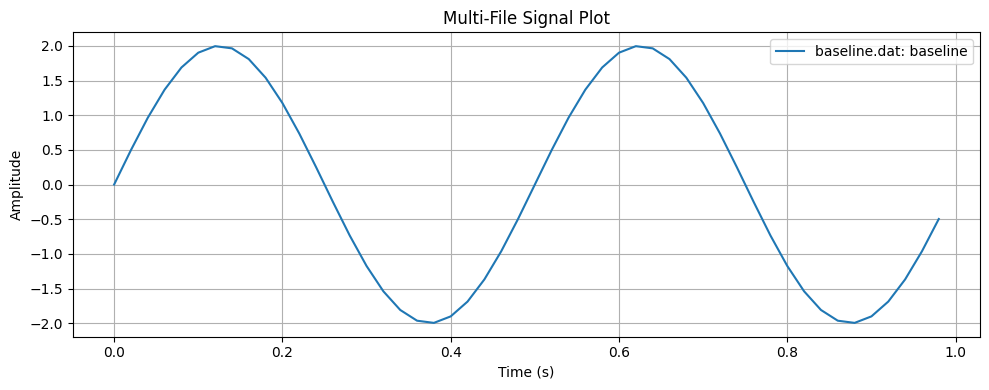

In [28]:
%cd /content/truefloat
from multi_plot import main as plot_waves
plot_waves(["baseline/baseline.dat"])

## Generate TrueFloat custom floating-point variants
After the baseline has been generated you may generate some variants with a custom precision floating-point format of your choice passing the `--fp-format` command line option.

As an example, we can generate the following variants:
- e5m5b-15nih
- e4m4b-7nih
- e5m3b-15nih

Since the above custom formats are far from comparable in precision with the original double precision representation, it may be useful to disable the embedded automatic verification against the input representation, since it will be way off the golden values. To do so use the `-DCUSTOM_VERIFICATION` command line option.

In [29]:
%mkdir -p /content/truefloat/e5m5b_15nih
%cd /content/truefloat/e5m5b_15nih
!bambu ../sine_table_gen.cpp --top-fname=sine_table_gen -lm --fp-format=@*e5m5b-15nih --fp-format-propagate -DCUSTOM_VERIFICATION --generate-tb=../sine_gen.cpp --tb-arg=50 --tb-arg=2 --tb-arg=2 --tb-arg=50 --tb-arg=e5m5b_15nih.dat --simulate --print-dot -v4 |& tee log.txt

Streaming output truncated to the last 5000 lines.
      Source: CONSTANT_11111 Target: ui_extract_bit_expr_FU_552_i0(1)  connected by: DIRECT_CONNECTION
      Source: CONSTANT_111110 Target: ui_extract_bit_expr_FU_482_i0(1)  connected by: DIRECT_CONNECTION
      Source: CONSTANT_11111001110000000000000000000000000000000000000000000000000000 Target: __float_mule11m52b_1023nih_953_i0(1)  connected by: MUX_TREE [4] => MUX_322___float_mule11m52b_1023nih_953_i0_1_0_8(T)
      Source: CONSTANT_11111001110100010001000010110100000000000000000000000000000000 Target: __float_mule11m52b_1023nih_953_i0(1)  connected by: MUX_TREE [4] => MUX_322___float_mule11m52b_1023nih_953_i0_1_0_8(F)
      Source: CONSTANT_111111 Target: ui_extract_bit_expr_FU_330_i0(1)  connected by: DIRECT_CONNECTION
      Source: CONSTANT_111111 Target: ui_extract_bit_expr_FU_449_i0(1)  connected by: DIRECT_CONNECTION
      Source: CONSTANT_111111 Target: ui_extract_bit_expr_FU_685_i0(1)  connected by: DIRECT_CONNECTION
    

In [30]:
%mkdir -p /content/truefloat/e4m4b_7nih
%cd /content/truefloat/e4m4b_7nih
!bambu ../sine_table_gen.cpp --top-fname=sine_table_gen -lm --fp-format=@*e4m4b-7nih --fp-format-propagate -DCUSTOM_VERIFICATION --generate-tb=../sine_gen.cpp --tb-arg=50 --tb-arg=2 --tb-arg=2 --tb-arg=50 --tb-arg=e4m4b_7nih.dat --simulate --print-dot -v4 |& tee log.txt

Streaming output truncated to the last 5000 lines.
      Source: CONSTANT_11100 Target: ui_extract_bit_expr_FU_99_i0(1)  connected by: DIRECT_CONNECTION
      Source: CONSTANT_111000 Target: ui_extract_bit_expr_FU_476_i0(1)  connected by: DIRECT_CONNECTION
      Source: CONSTANT_11100000 Target: lut_expr_FU_806_i0(0)  connected by: DIRECT_CONNECTION
      Source: CONSTANT_111001 Target: ui_extract_bit_expr_FU_477_i0(1)  connected by: DIRECT_CONNECTION
      Source: CONSTANT_11100101111011100000111001101000100101001000000100100111000001 Target: __float_mule11m52b_1023nih_953_i0(1)  connected by: MUX_TREE [5] => MUX_322___float_mule11m52b_1023nih_953_i0_1_0_4(T)
      Source: CONSTANT_11100111110000000110111000001110000000000000000000000000000000 Target: __float_mule11m52b_1023nih_953_i0(1)  connected by: MUX_TREE [5] => MUX_322___float_mule11m52b_1023nih_953_i0_1_0_4(F)
      Source: CONSTANT_11101 Target: ui_extract_bit_expr_FU_100_i0(1)  connected by: DIRECT_CONNECTION
      Source: C

In [31]:
%mkdir -p /content/truefloat/e5m3b_15nih
%cd /content/truefloat/e5m3b_15nih
!bambu ../sine_table_gen.cpp --top-fname=sine_table_gen -lm --fp-format=@*e5m3b-15nih --fp-format-propagate -DCUSTOM_VERIFICATION --generate-tb=../sine_gen.cpp --tb-arg=50 --tb-arg=2 --tb-arg=2 --tb-arg=50 --tb-arg=e5m3b_15nih.dat --simulate --print-dot -v4 |& tee log.txt

Streaming output truncated to the last 5000 lines.
      Source: CONSTANT_111000 Target: ui_extract_bit_expr_FU_476_i0(1)  connected by: DIRECT_CONNECTION
      Source: CONSTANT_11100000 Target: lut_expr_FU_806_i0(0)  connected by: DIRECT_CONNECTION
      Source: CONSTANT_111001 Target: ui_extract_bit_expr_FU_477_i0(1)  connected by: DIRECT_CONNECTION
      Source: CONSTANT_11100101111011100000111001101000100101001000000100100111000001 Target: __float_mule11m52b_1023nih_953_i0(1)  connected by: MUX_TREE [5] => MUX_322___float_mule11m52b_1023nih_953_i0_1_0_4(T)
      Source: CONSTANT_11100111110000000110111000001110000000000000000000000000000000 Target: __float_mule11m52b_1023nih_953_i0(1)  connected by: MUX_TREE [5] => MUX_322___float_mule11m52b_1023nih_953_i0_1_0_4(F)
      Source: CONSTANT_11101 Target: ui_extract_bit_expr_FU_100_i0(1)  connected by: DIRECT_CONNECTION
      Source: CONSTANT_11101 Target: ui_extract_bit_expr_FU_194_i0(1)  connected by: DIRECT_CONNECTION
      Source: 

## Look at the output
After the different variants have been generated, it is time to have a look at the generated output to verify the impact of the different custom floating-point formats on the application results.

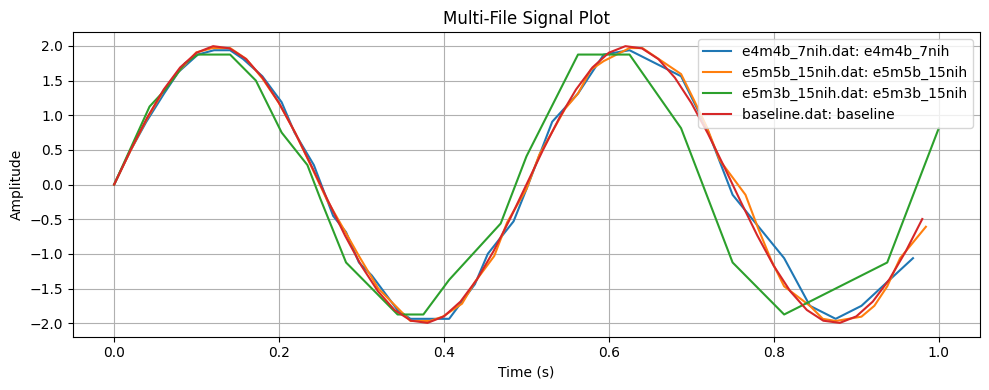

In [32]:
from pathlib import Path

base_dir = Path("/content/truefloat")
dat_files = []

for subdir in base_dir.iterdir():
    if subdir.is_dir():
        dat_files.extend(subdir.glob("*.dat"))

plot_waves(dat_files)